# ADAML - NASA Turbofan A

**Team members:** Radomir Babek, Vojtech Vondracek, Jakub Rysanek

**Goal:** creation of KPLS models using 4 train/test datasets, predicting remaining useful life

In [13]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["PYTHONWARNINGS"] = (
    "ignore:y residual is constant at iteration:UserWarning:sklearn.cross_decomposition._pls"
)

import warnings
warnings.filterwarnings(
    "ignore",
    message=r"y residual is constant at iteration \d+",
    category=UserWarning,
    module=r"sklearn\.cross_decomposition\._pls"
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics.pairwise import rbf_kernel, laplacian_kernel, chi2_kernel
from sklearn.preprocessing import KernelCenterer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from optimizer import optimize
from kernel import cauchy_kernel, polynomial_kernel


## Data loading

In [14]:
def filter_no_variance(data):
    # Select only sensor columns
    sensor_cols = [col for col in data.columns if "sensor measurement" in col]

    # # Keep only sensors with non-zero variance and with their orig index
    valid_cols = []
    filtered_cols = []
    for i, col in enumerate(sensor_cols):
        if data[col].var() > 1e-8:
            valid_cols.append((i, col))
        else:
            filtered_cols.append(col)

    print("Zero variance columns (constant values):", filtered_cols)

    data = data.drop(columns=filtered_cols)
    return data, filtered_cols

def add_mean_max_min_column(data, window = 25):
  sensor_cols = [c for c in data.columns if "sensor measurement" in c]
  for i, col in enumerate(sensor_cols):
      # SM1_mean is mean of window values from sensor measurement 1
      data[f"SM{i+1}_mean" ] = data.groupby("unit number")[col].transform(
          lambda x: x.rolling(window=window, min_periods=1).mean()
      )
      data[f"SM{i+1}_max"] = data.groupby("unit number")[col].transform(
          lambda x: x.rolling(window=window, min_periods=1).max()
      )
      data[f"SM{i+1}_min"] = data.groupby("unit number")[col].transform(
          lambda x: x.rolling(window=window, min_periods=1).min()
      )

def from_file(train_file_name):
    names = [
      "unit number",
      "time, in cycles",
      "operational setting 1",
      "operational setting 2",
      "operational setting 3"
        ]

    sen_measurements = [f"sensor measurement {i}" for i in range(1, 22)]
    names = names + sen_measurements
    data = pd.read_csv(train_file_name, sep=r'\s+', names=names)

    return data

def train_from_file(file_name, validation_partition = 0.2):
    data = from_file(file_name)

    data, filtered_cols = filter_no_variance(data)
    add_mean_max_min_column(data)

    #COUNTING RUL
    units = dict(tuple(data.groupby("unit number")))
    new_units = []
    for u_id in units:
        u = units[u_id]
        u = u.drop(columns=[
                        "operational setting 1",
                        "operational setting 2",
                        "operational setting 3"])

        failure_time = u.shape[0] + 1
        u["RUL"] = failure_time - u["time, in cycles"]
        new_units.append(u)

    units = new_units

    # SPLITTING VALIDATION / TRAIN
    validation_unit_count = math.ceil(len(units) * validation_partition)
    np.random.seed(42)
    np.random.shuffle(units)

    validation_units = units[:validation_unit_count]
    train_units = units[validation_unit_count:]

    validation_data = pd.concat(validation_units)
    train_data = pd.concat(train_units)

    return train_data, validation_data, filtered_cols

def test_from_file(file_name, gt_file_name, dropped_cols):
    data = from_file(file_name)
    data = data.drop(columns=dropped_cols)

    add_mean_max_min_column(data)

    #read file, where there is only one number on a line into a vector of these numbers
    gt = np.loadtxt(gt_file_name)

    #COUNTING RUL
    units = dict(tuple(data.groupby("unit number")))
    new_units = []
    i = 0
    for u_id in units:
        u = units[u_id]
        u = u.drop(columns=[
                        "operational setting 1",
                        "operational setting 2",
                        "operational setting 3"])
        RUL = gt[i]
        u["RUL"] = int(RUL + u.shape[0] + 1) - u["time, in cycles"]
        i += 1
        new_units.append(u)

    units = new_units

    test_data = pd.concat(units)
    return test_data

## Data normalization

In [15]:
def normalizeRUL(Y, y_min, y_max):
    Y_scaled = (Y - y_min) / (y_max - y_min)
    return Y_scaled

def normalize_data(train_data, validation_data, test_data, normRUL=False):
    sensor_cols = [
        c for c in train_data.columns 
        if (("sensor measurement" in c) or ("mean" in c) or ("max" in c) or ("min" in c))
        and c not in ["unit number", "time_in_cycles"]
    ]
    print(sensor_cols)

    mu_train = train_data[sensor_cols].mean(axis=0)
    sd_train = train_data[sensor_cols].std(axis=0, ddof=0)

    sd_r = sd_train.replace(0, 1)  # prevence dělení nulou

    train_data[sensor_cols]      = (train_data[sensor_cols     ] - mu_train) / sd_r
    validation_data[sensor_cols] = (validation_data[sensor_cols] - mu_train) / sd_r
    test_data[sensor_cols]       = (test_data[sensor_cols      ] - mu_train) / sd_r

    #Normalize RUL
    if normRUL==True:
        y_min, y_max = train_data["RUL"].min(), train_data["RUL"].max()
        train_data["RUL"] = normalizeRUL(train_data["RUL"], y_min, y_max)
        validation_data["RUL"] = normalizeRUL(validation_data["RUL"], y_min, y_max)
        test_data["RUL"] = normalizeRUL(test_data["RUL"], y_min, y_max)

    return train_data, validation_data, test_data, mu_train, sd_train

## Subsampling of overly large datasets

In [16]:
def subsample_time_series(df, target_rows=20000, unit_col="unit number",
                          order_col=None, keep_tail=50, min_per_unit=40, seed=42):
    """
    Model-agnostic thinning:
      - keep last `keep_tail` rows of every unit
      - allocate the remaining budget across units proportionally to their length
      - uniformly sample (by order index) from the early part
    """
    import numpy as np, pandas as pd

    rng = np.random.RandomState(seed)
    groups = {u: g.sort_values(order_col) if order_col else g
              for u, g in df.groupby(unit_col, sort=False)}

    # 1) keep tails
    tails = [g.tail(keep_tail) if len(g) > keep_tail else g for g in groups.values()]
    tail_df = pd.concat(tails, ignore_index=False).drop_duplicates()
    remaining = max(0, target_rows - len(tail_df))

    if remaining <= 0:
        return tail_df.sample(n=target_rows, random_state=seed)

    # 2) heads to sample from
    heads = {u: (g.iloc[:-keep_tail] if len(g) > keep_tail else g.iloc[0:0])
             for u, g in groups.items()}
    head_sizes = {u: len(h) for u, h in heads.items()}
    total_head = sum(head_sizes.values())
    if total_head == 0:
        return tail_df.sample(n=target_rows, random_state=seed)

    # 3) allocate samples per unit proportionally (with a minimum)
    alloc = {u: 0 for u in heads}
    for u, n in head_sizes.items():
        if n > 0:
            alloc[u] = int(round(remaining * (n / total_head)))

    # enforce per-unit min where possible
    # (then trim back to exact target by removing from largest allocations)
    for u, n in head_sizes.items():
        if n > 0:
            alloc[u] = min(n, max(min_per_unit, alloc[u]))
    diff = remaining - sum(alloc.values())
    if diff != 0:
        # adjust by ±1 starting from units with largest heads
        by_need = sorted(head_sizes.items(), key=lambda kv: kv[1], reverse=True)
        i = 0
        while diff != 0 and i < len(by_need):
            u, n = by_need[i]
            cap = (n - alloc[u]) if diff > 0 else alloc[u]
            if cap > 0:
                alloc[u] += 1 if diff > 0 else -1
                diff += -1 if diff > 0 else 1
            else:
                i += 1

    # 4) sample within each head uniformly by index (order-aware, no label peeking)
    picks = []
    for u, h in heads.items():
        k = alloc[u]
        if k <= 0 or len(h) == 0:
            continue
        idx = np.linspace(0, len(h) - 1, num=k, dtype=int)
        picks.append(h.iloc[idx])

    sampled_heads = pd.concat(picks, ignore_index=False) if picks else df.iloc[0:0]
    sub = pd.concat([sampled_heads, tail_df], ignore_index=False).sort_index()
    # if any rounding drift remains, fix it exactly
    if len(sub) > target_rows:
        sub = sub.sample(n=target_rows, random_state=seed)
    return sub


## KPLS

In [ ]:
def fit_model(X,y, n_lv, kernel_f, gamma):
    K_train = kernel_f(X, X, gamma=gamma)
    centerer = KernelCenterer()
    K_train_c = centerer.fit_transform(K_train)
    
    pls = PLSRegression(n_lv, scale=False)
    pls.fit(K_train_c, y)
    return pls, centerer

def count_q2(y_val, y_pred, y_train):
    ss_res = np.sum((y_val - y_pred.ravel())**2) 
    ss_tot = np.sum((y_val - np.mean(y_train))**2)
    return 1 - ss_res/ss_tot 

def predict(X_train, y_train, X, y, pls, centerer, gamma, kernel_f):
    K_validation   = kernel_f(X, X_train, gamma=gamma)
    K_validation_c = centerer.transform(K_validation)
    y_pred = pls.predict(K_validation_c).ravel()

    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae  = mean_absolute_error(y, y_pred)
    q2   = count_q2(y, y_pred, y_train)

    return rmse, mae, q2

def create_train_subset(train_data, n_rows):
    rng = np.random.RandomState(42)
    unit_ids = train_data["unit number"].unique()
    rng.shuffle(unit_ids)

    selected_units = []
    row_count = 0
    for uid in unit_ids:
        unit_rows = train_data[train_data["unit number"] == uid]
        row_count += len(unit_rows)
        selected_units.append(uid)
        if row_count >= n_rows:
            break

    return train_data[train_data["unit number"].isin(selected_units)]


def fit_kpls(train_data, validation_data, kernel_f=rbf_kernel, method_name="RBF_kernel", max_lv=13, train_subset_size=None, n_jobs=1):
    output = []

    if train_subset_size:
        print("Performing optimization on train dataset subset,")
        train_data = create_train_subset(train_data, train_subset_size)
    else:
        print("Performing optimization on whole train dataset")

    # optimize gamma on training data
    opt_results = optimize(train_data, max_lv, folds=3, kernel_f=kernel_f, method_name=method_name, n_jobs=n_jobs)
    best_row = opt_results.loc[opt_results["q2"].idxmax()]
    print(f"Best CV n_lv={int(best_row.n_lv)}, gamma={best_row.gamma:.6g}, Q^2={best_row.q2:.4f}")

    # prepare datasets with only sensor data
    X_train = train_data.iloc[:, 2:-1]
    y_train = train_data.iloc[:, -1]

    X_validation = validation_data.iloc[:, 2:-1]
    y_validation = validation_data.iloc[:, -1]

    # eval validation (or the remaining unseen) dataset - test for generalization
    for i,res in opt_results.iterrows():
        gamma = res["gamma"]
        n_lv = int(res["n_lv"])
        cv_q2   = res["q2"]
        if (cv_q2 < 0.2):
            print(f"Skipping eval {i} -> cv Q^2 is less than 0.2")
            continue

        print(f"Evaluate n. {i}, gamma={gamma}, n_lv={n_lv}")
        pls, centerer = fit_model(X_train, y_train, n_lv, kernel_f, gamma)

        validation_rmse, validation_mae, validation_q2 = predict(
            X_train, y_train, X_validation, y_validation, pls, centerer, gamma, kernel_f)

        output.append({
            "n_lv": n_lv,
            "gamma": gamma,
            "q2_validation": validation_q2,
            "q2_train_cv": cv_q2,
            "rmse_val": validation_rmse,
            "mae_val": validation_mae,
            "method_name": method_name,
            "kernel_f": kernel_f
        })

    return pd.DataFrame(output)

def eval_test(test_data, train_data, train_results, kernel_f, method_name):
    X_train = train_data.iloc[:, 2:-1]
    y_train = train_data.iloc[:, -1]
    X_test = test_data.iloc[:, 2:-1]
    y_test = test_data.iloc[:, -1]

    best_row_train = train_results.loc[train_results["q2_train_cv"].idxmax()]
    best_row_val = train_results.loc[train_results["q2_validation"].idxmax()]

    def eval_row(row):
        gamma = row["gamma"]
        n_lv = int(row["n_lv"])
        
        print("Fitting model")
        pls, centerer = fit_model(X_train, y_train, n_lv, kernel_f, gamma)

        print("predicting on test data")
        rmse, mae, q2 = predict(X_train, y_train, X_test, y_test, pls, centerer, gamma, kernel_f)

        test_row = row.copy()
        test_row["rmse_test"] = rmse
        test_row["mae_test"] = mae
        test_row["q2_test"] = q2
        test_row["method"] = f"{method_name}"
        return test_row

    output = [eval_row(best_row_train)]

    if best_row_train.name != best_row_val.name:
        output.append(eval_row(best_row_val))

    return pd.DataFrame(output)

def plot_unit(train_data, test_data, params, dataset_name, unit_id):
    gamma = params.gamma
    n_lv = params.n_lv
    kernel_f = params.kernel_f
    method = params.method_name

    X_train = train_data.iloc[:, 2:-1]
    y_train = train_data.iloc[:, -1]

    pls, centerer = fit_model(X_train, y_train, n_lv, kernel_f, gamma)
    test_unit = test_data[test_data["unit number"] == unit_id]

    Xunit = test_unit.iloc[:, 2:-1].to_numpy()
    K_unit = kernel_f(Xunit, X_train, gamma=gamma)
    Kunit_c = centerer.transform(K_unit)
    Yunit = test_unit["RUL"].to_numpy()

    # Predict
    Ypred = pls.predict(Kunit_c).ravel()
    Ypred = np.clip(Ypred, 0, None)

    rmse_unit = np.sqrt(mean_squared_error(Yunit, Ypred))

    plt.figure(figsize=(5, 5))
    plt.scatter(Yunit, Ypred, s=15, c="tab:blue", alpha=0.7)
    plt.plot([Yunit.min(), Yunit.max()], [Yunit.min(), Yunit.max()], "k--", lw=1.2)
    plt.xlabel("Observed RUL")
    plt.ylabel("Predicted RUL")

    plt.title(
        f"{dataset_name} — Unit {unit_id}\n"
        f"{method}, γ={gamma:.3g}, n_lv={n_lv}, RMSE={rmse_unit:.3f}"
    )

    plt.grid(True)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

def process_dataset(train_data, validation_data, test_data, dataset_name, max_lv=12, train_subset_size=None, n_jobs=1):
    print("Polynomial kernel")
    train_results_polynomial = fit_kpls(train_data, validation_data, kernel_f=polynomial_kernel, method_name="Polynomial", max_lv=max_lv, train_subset_size=train_subset_size, n_jobs=n_jobs)
    if len(train_results_polynomial):
        test_results_polynomial = eval_test(test_data, train_data, train_results_polynomial, kernel_f=polynomial_kernel, method_name="Polynomial")

    
    print("RBF kernel")
    train_results_rbf = fit_kpls(train_data, validation_data, kernel_f=rbf_kernel, method_name="RBF", max_lv=max_lv, train_subset_size=train_subset_size, n_jobs=n_jobs)
    if len(train_results_rbf):
        test_results_rbf = eval_test(test_data, train_data, train_results_rbf, kernel_f=rbf_kernel, method_name="RBF")

    print("Cauchy kernel")
    train_results_cauchy = fit_kpls(train_data, validation_data, kernel_f=cauchy_kernel, method_name="Cauchy", max_lv=max_lv, train_subset_size=train_subset_size, n_jobs=n_jobs)
    if len(train_results_cauchy):
        test_results_cauchy = eval_test(test_data, train_data, train_results_cauchy, kernel_f=cauchy_kernel, method_name="Cauchy")

    train_results_all = pd.concat(
        [train_results_rbf, train_results_polynomial, train_results_cauchy],
        ignore_index=True
    )
    train_results_all.drop(columns=["kernel_f"], inplace=True)
    train_results_all.to_csv(dataset_name + "_train.csv")

    test_results_all = pd.concat(
        [test_results_rbf, test_results_polynomial, test_results_cauchy],
        ignore_index=True
    )

    if not len(test_results_all):
        print(f"{dataset_name} - No suitable model was found")

    best_row_train = test_results_all.loc[test_results_all["rmse_test"].idxmin()]

    units_to_plot = [10, 20, 40]
    for unit_id in units_to_plot:
        plot_unit(train_data, test_data, best_row_train, dataset_name, unit_id)
    
    test_results_all.drop(columns=["kernel_f"], inplace=True)
    test_results_all.to_csv(dataset_name + "_test.csv")

## Modeling and evaluation

Zero variance columns (constant values): ['sensor measurement 1', 'sensor measurement 5', 'sensor measurement 10', 'sensor measurement 16', 'sensor measurement 18', 'sensor measurement 19']
['sensor measurement 2', 'sensor measurement 3', 'sensor measurement 4', 'sensor measurement 6', 'sensor measurement 7', 'sensor measurement 8', 'sensor measurement 9', 'sensor measurement 11', 'sensor measurement 12', 'sensor measurement 13', 'sensor measurement 14', 'sensor measurement 15', 'sensor measurement 17', 'sensor measurement 20', 'sensor measurement 21', 'SM1_mean', 'SM1_max', 'SM1_min', 'SM2_mean', 'SM2_max', 'SM2_min', 'SM3_mean', 'SM3_max', 'SM3_min', 'SM4_mean', 'SM4_max', 'SM4_min', 'SM5_mean', 'SM5_max', 'SM5_min', 'SM6_mean', 'SM6_max', 'SM6_min', 'SM7_mean', 'SM7_max', 'SM7_min', 'SM8_mean', 'SM8_max', 'SM8_min', 'SM9_mean', 'SM9_max', 'SM9_min', 'SM10_mean', 'SM10_max', 'SM10_min', 'SM11_mean', 'SM11_max', 'SM11_min', 'SM12_mean', 'SM12_max', 'SM12_min', 'SM13_mean', 'SM13_max',

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 3, gamma: 0.4224156770182361, q2: 0.3375725680298766
n_lv: 1, gamma: 9.999545365071553, q2: 0.24828471450581946
n_lv: 2, gamma: 9.999338996493444, q2: 0.32803050897626485
n_lv: 4, gamma: 0.002821711119806473, q2: 0.6103872502956519
n_lv: 5, gamma: 0.0015985578993200698, q2: 0.6169023530476235


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  2.8min


n_lv: 6, gamma: 9.999338996493444, q2: 0.3497170985311194
n_lv: 7, gamma: 9.999388624095117, q2: 0.3603315515768385
n_lv: 8, gamma: 9.99940779074933, q2: 0.36431677434996085
n_lv: 9, gamma: 9.999339163419158, q2: 0.3544647492232001
n_lv: 10, gamma: 9.999457454017, q2: 0.35456982910686247


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  5.4min


n_lv: 11, gamma: 9.999338996493444, q2: 0.3517834713156769
n_lv: 12, gamma: 0.007829997410721665, q2: 0.6149798912808444
n_lv: 13, gamma: 0.015397394067867652, q2: 0.6133343286319399
n_lv: 15, gamma: 0.014875001683489921, q2: 0.6065693978063296
n_lv: 14, gamma: 0.015999974050450196, q2: 0.6074052638999845
n_lv: 16, gamma: 0.09487711521918409, q2: 0.5873907921362977


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed:  8.3min remaining:  2.1min


n_lv: 17, gamma: 0.10886246224811928, q2: 0.5818477161670002
n_lv: 18, gamma: 0.1133459711767185, q2: 0.579064525903718
n_lv: 19, gamma: 0.12104754901749493, q2: 0.5764324649146728
n_lv: 20, gamma: 0.1279936829933154, q2: 0.5735233831809273


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed: 10.3min finished


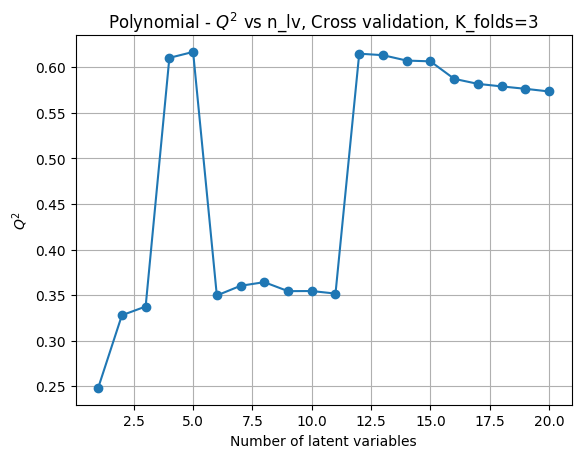

Best CV n_lv=5, gamma=0.00159856, Q^2=0.6169
Evaluate n. 0, gamma=9.999545365071553, n_lv=1
Evaluate n. 1, gamma=9.999338996493444, n_lv=2
Evaluate n. 2, gamma=0.4224156770182361, n_lv=3
Evaluate n. 3, gamma=0.002821711119806473, n_lv=4
Evaluate n. 4, gamma=0.0015985578993200698, n_lv=5
Evaluate n. 5, gamma=9.999338996493444, n_lv=6
Evaluate n. 6, gamma=9.999388624095117, n_lv=7
Evaluate n. 7, gamma=9.99940779074933, n_lv=8
Evaluate n. 8, gamma=9.999339163419158, n_lv=9
Evaluate n. 9, gamma=9.999457454017, n_lv=10
Evaluate n. 10, gamma=9.999338996493444, n_lv=11
Evaluate n. 11, gamma=0.007829997410721665, n_lv=12
Evaluate n. 12, gamma=0.015397394067867652, n_lv=13
Evaluate n. 13, gamma=0.015999974050450196, n_lv=14
Evaluate n. 14, gamma=0.014875001683489921, n_lv=15
Evaluate n. 15, gamma=0.09487711521918409, n_lv=16
Evaluate n. 16, gamma=0.10886246224811928, n_lv=17
Evaluate n. 17, gamma=0.1133459711767185, n_lv=18
Evaluate n. 18, gamma=0.12104754901749493, n_lv=19
Evaluate n. 19, gamm

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 2, gamma: 0.0425704064038881, q2: 0.42528644661355
n_lv: 1, gamma: 0.0005325555567403421, q2: 0.48450489414603976
n_lv: 3, gamma: 0.0032741012270299857, q2: 0.5545583535422424
n_lv: 4, gamma: 0.002795124109398102, q2: 0.6166945063153764
n_lv: 5, gamma: 0.0047031852676665716, q2: 0.6229576400865349


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  2.4min


n_lv: 6, gamma: 0.003734475229186615, q2: 0.6283730299523492
n_lv: 7, gamma: 0.01835696459723847, q2: 0.62130687078611
n_lv: 8, gamma: 0.006788391207866422, q2: 0.629610776754921
n_lv: 9, gamma: 0.0079101692085904, q2: 0.628803484307548
n_lv: 10, gamma: 0.009038260382157168, q2: 0.6266608159471533


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  4.5min


n_lv: 11, gamma: 0.00758916988865477, q2: 0.6221072176172404
n_lv: 12, gamma: 0.011281412140627951, q2: 0.6180197542921224
n_lv: 13, gamma: 0.013764807718571456, q2: 0.6113416777793809
n_lv: 15, gamma: 0.007439764448149741, q2: 0.605838848002512
n_lv: 14, gamma: 0.008512594361561609, q2: 0.6069353355949101
n_lv: 16, gamma: 0.003128457489133959, q2: 0.6060642334987347


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed:  7.2min remaining:  1.8min


n_lv: 17, gamma: 0.002991305956895244, q2: 0.6052095779054725
n_lv: 19, gamma: 0.003128457489133959, q2: 0.6044257812507374
n_lv: 18, gamma: 0.0013967798242937948, q2: 0.6058356374643267
n_lv: 20, gamma: 0.004215629442553446, q2: 0.6053437705769432


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed:  9.5min finished


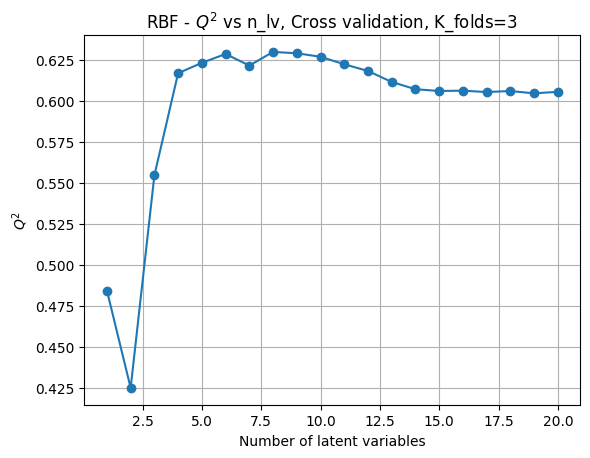

Best CV n_lv=8, gamma=0.00678839, Q^2=0.6296
Evaluate n. 0, gamma=0.0005325555567403421, n_lv=1
Evaluate n. 1, gamma=0.0425704064038881, n_lv=2
Evaluate n. 2, gamma=0.0032741012270299857, n_lv=3
Evaluate n. 3, gamma=0.002795124109398102, n_lv=4
Evaluate n. 4, gamma=0.0047031852676665716, n_lv=5
Evaluate n. 5, gamma=0.003734475229186615, n_lv=6
Evaluate n. 6, gamma=0.01835696459723847, n_lv=7
Evaluate n. 7, gamma=0.006788391207866422, n_lv=8
Evaluate n. 8, gamma=0.0079101692085904, n_lv=9
Evaluate n. 9, gamma=0.009038260382157168, n_lv=10
Evaluate n. 10, gamma=0.00758916988865477, n_lv=11
Evaluate n. 11, gamma=0.011281412140627951, n_lv=12
Evaluate n. 12, gamma=0.013764807718571456, n_lv=13
Evaluate n. 13, gamma=0.008512594361561609, n_lv=14
Evaluate n. 14, gamma=0.007439764448149741, n_lv=15
Evaluate n. 15, gamma=0.003128457489133959, n_lv=16
Evaluate n. 16, gamma=0.002991305956895244, n_lv=17
Evaluate n. 17, gamma=0.0013967798242937948, n_lv=18
Evaluate n. 18, gamma=0.0031284574891339

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 4, gamma: 8.451429308814431, q2: 0.549169825498389
n_lv: 3, gamma: 11.61874158217542, q2: 0.4850028324327988
n_lv: 1, gamma: 13.778049964917718, q2: 0.3511043932469147
n_lv: 2, gamma: 13.778049964917718, q2: 0.4414779527411162
n_lv: 6, gamma: 1.6307552889356263, q2: 0.6034014765213598


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  1.7min


n_lv: 5, gamma: 0.007268755645441535, q2: 0.6231949122011138
n_lv: 9, gamma: 2.6461645545511336, q2: 0.5910431833112998
n_lv: 8, gamma: 0.04821296542308415, q2: 0.6219883698470693
n_lv: 10, gamma: 2.696006058413146, q2: 0.5913964450166767
n_lv: 7, gamma: 0.002961387762959877, q2: 0.6327386940278988


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  3.0min


n_lv: 11, gamma: 2.2985409506451107, q2: 0.5947739142398559
n_lv: 12, gamma: 2.836684885547117, q2: 0.5929941472345814
n_lv: 13, gamma: 2.4413571421250184, q2: 0.5965342214536785
n_lv: 14, gamma: 2.2515067656201575, q2: 0.5979593438955515
n_lv: 16, gamma: 2.0774502786382065, q2: 0.5976923601991686
n_lv: 15, gamma: 1.874018366203716, q2: 0.59926580892537


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed:  5.2min remaining:  1.3min


n_lv: 17, gamma: 1.9906450364013724, q2: 0.5988273647639464
n_lv: 18, gamma: 1.9323865241328437, q2: 0.598905884942597
n_lv: 20, gamma: 2.0437306291344575, q2: 0.5985785949332243
n_lv: 19, gamma: 1.7400688583179635, q2: 0.5996558395773205


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed:  6.6min finished


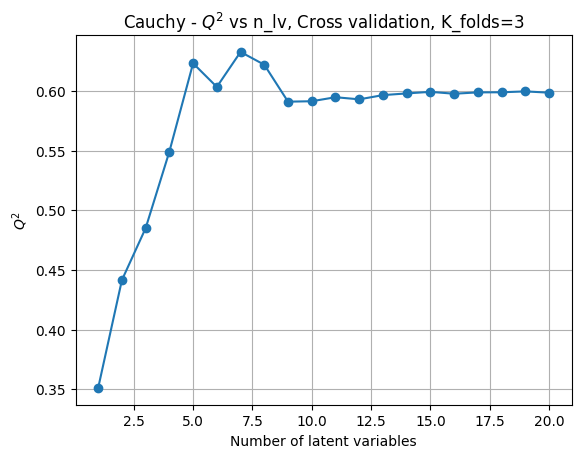

Best CV n_lv=7, gamma=0.00296139, Q^2=0.6327
Evaluate n. 0, gamma=13.778049964917718, n_lv=1
Evaluate n. 1, gamma=13.778049964917718, n_lv=2
Evaluate n. 2, gamma=11.61874158217542, n_lv=3
Evaluate n. 3, gamma=8.451429308814431, n_lv=4
Evaluate n. 4, gamma=0.007268755645441535, n_lv=5
Evaluate n. 5, gamma=1.6307552889356263, n_lv=6
Evaluate n. 6, gamma=0.002961387762959877, n_lv=7
Evaluate n. 7, gamma=0.04821296542308415, n_lv=8
Evaluate n. 8, gamma=2.6461645545511336, n_lv=9
Evaluate n. 9, gamma=2.696006058413146, n_lv=10
Evaluate n. 10, gamma=2.2985409506451107, n_lv=11
Evaluate n. 11, gamma=2.836684885547117, n_lv=12
Evaluate n. 12, gamma=2.4413571421250184, n_lv=13
Evaluate n. 13, gamma=2.2515067656201575, n_lv=14
Evaluate n. 14, gamma=1.874018366203716, n_lv=15
Evaluate n. 15, gamma=2.0774502786382065, n_lv=16
Evaluate n. 16, gamma=1.9906450364013724, n_lv=17
Evaluate n. 17, gamma=1.9323865241328437, n_lv=18
Evaluate n. 18, gamma=1.7400688583179635, n_lv=19
Evaluate n. 19, gamma=2.

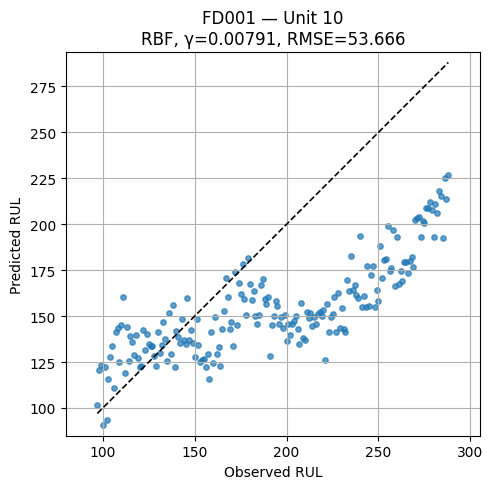

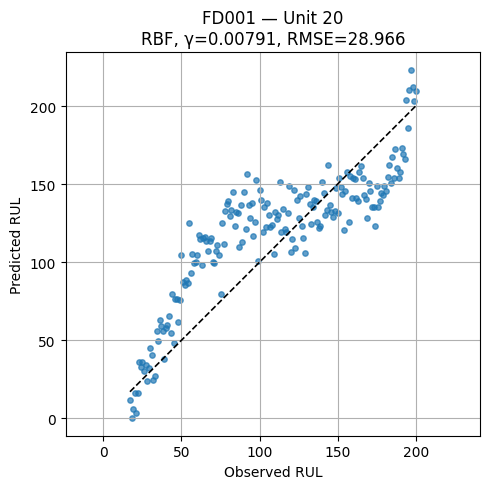

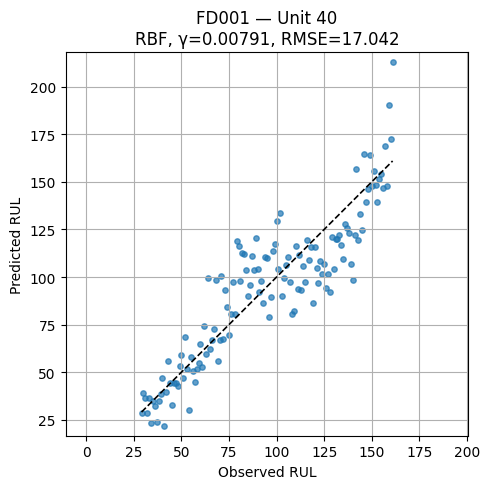

Zero variance columns (constant values): []
['sensor measurement 1', 'sensor measurement 2', 'sensor measurement 3', 'sensor measurement 4', 'sensor measurement 5', 'sensor measurement 6', 'sensor measurement 7', 'sensor measurement 8', 'sensor measurement 9', 'sensor measurement 10', 'sensor measurement 11', 'sensor measurement 12', 'sensor measurement 13', 'sensor measurement 14', 'sensor measurement 15', 'sensor measurement 16', 'sensor measurement 17', 'sensor measurement 18', 'sensor measurement 19', 'sensor measurement 20', 'sensor measurement 21', 'SM1_mean', 'SM1_max', 'SM1_min', 'SM2_mean', 'SM2_max', 'SM2_min', 'SM3_mean', 'SM3_max', 'SM3_min', 'SM4_mean', 'SM4_max', 'SM4_min', 'SM5_mean', 'SM5_max', 'SM5_min', 'SM6_mean', 'SM6_max', 'SM6_min', 'SM7_mean', 'SM7_max', 'SM7_min', 'SM8_mean', 'SM8_max', 'SM8_min', 'SM9_mean', 'SM9_max', 'SM9_min', 'SM10_mean', 'SM10_max', 'SM10_min', 'SM11_mean', 'SM11_max', 'SM11_min', 'SM12_mean', 'SM12_max', 'SM12_min', 'SM13_mean', 'SM13_max

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 1, gamma: 0.001661003506557609, q2: 0.04450690842143168
n_lv: 2, gamma: 0.0038000557871437587, q2: 0.05969302319425607
n_lv: 3, gamma: 0.001661003506557609, q2: 0.09957044284417349
n_lv: 4, gamma: 0.002730529646850684, q2: 0.1673811562033371
n_lv: 5, gamma: 0.001661003506557609, q2: 0.33130248049055266


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  5.8min


n_lv: 6, gamma: 0.001661003506557609, q2: 0.4256743890950322
n_lv: 7, gamma: 0.001661003506557609, q2: 0.4735983063503933
n_lv: 8, gamma: 0.00149601132408542, q2: 0.5442896588946085
n_lv: 9, gamma: 0.001661003506557609, q2: 0.5958967451485533
n_lv: 10, gamma: 0.0014028594171784747, q2: 0.6161177291252454


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed: 10.0min


n_lv: 11, gamma: 0.0023706081944457826, q2: 0.6228535161752786
n_lv: 12, gamma: 0.001661003506557609, q2: 0.6337732395020148
n_lv: 13, gamma: 0.0025245182824325573, q2: 0.6372321092319384
n_lv: 14, gamma: 0.002404951469683344, q2: 0.6408605216499689
n_lv: 15, gamma: 0.0014726067320256359, q2: 0.6454272195877511
n_lv: 16, gamma: 9.999589265780621, q2: 0.16246189372746966


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed: 16.2min remaining:  4.0min


n_lv: 17, gamma: 9.999420377442322, q2: 0.17775818296854579
n_lv: 18, gamma: 9.999643604424845, q2: 0.20301696503079908
n_lv: 19, gamma: 9.999526614343406, q2: 0.21667303065076432
n_lv: 20, gamma: 9.999461606612817, q2: 0.2400183202129798


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed: 20.9min finished


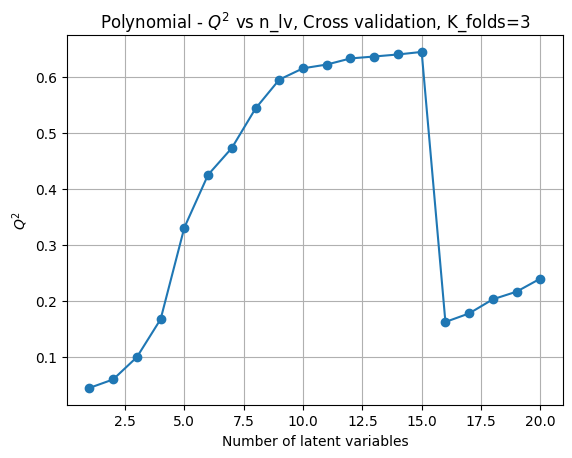

Best CV n_lv=15, gamma=0.00147261, Q^2=0.6454
Skipping eval 0 -> cv Q^2 is less than 0.2
Skipping eval 1 -> cv Q^2 is less than 0.2
Skipping eval 2 -> cv Q^2 is less than 0.2
Skipping eval 3 -> cv Q^2 is less than 0.2
Evaluate n. 4, gamma=0.001661003506557609, n_lv=5
Evaluate n. 5, gamma=0.001661003506557609, n_lv=6
Evaluate n. 6, gamma=0.001661003506557609, n_lv=7
Evaluate n. 7, gamma=0.00149601132408542, n_lv=8
Evaluate n. 8, gamma=0.001661003506557609, n_lv=9
Evaluate n. 9, gamma=0.0014028594171784747, n_lv=10
Evaluate n. 10, gamma=0.0023706081944457826, n_lv=11
Evaluate n. 11, gamma=0.001661003506557609, n_lv=12
Evaluate n. 12, gamma=0.0025245182824325573, n_lv=13
Evaluate n. 13, gamma=0.002404951469683344, n_lv=14
Evaluate n. 14, gamma=0.0014726067320256359, n_lv=15
Skipping eval 15 -> cv Q^2 is less than 0.2
Skipping eval 16 -> cv Q^2 is less than 0.2
Evaluate n. 17, gamma=9.999643604424845, n_lv=18
Evaluate n. 18, gamma=9.999526614343406, n_lv=19
Evaluate n. 19, gamma=9.99946160

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 1, gamma: 0.8200094967106035, q2: 0.25315597715023425
n_lv: 2, gamma: 0.9854341197457558, q2: 0.3288354420585219
n_lv: 3, gamma: 0.6822042878684775, q2: 0.4046643306910321
n_lv: 4, gamma: 0.46096514758399415, q2: 0.43877165641159505
n_lv: 5, gamma: 0.31056955346441995, q2: 0.48012811539065686


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  2.8min


n_lv: 7, gamma: 0.38470415107069045, q2: 0.521120979002353
n_lv: 6, gamma: 0.27011156782547757, q2: 0.5020734643461457
n_lv: 8, gamma: 0.3743854373804567, q2: 0.5345518699450944
n_lv: 9, gamma: 0.32384608045898183, q2: 0.5507420436617663
n_lv: 11, gamma: 0.2619373980634943, q2: 0.5657991209296644


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  6.3min


n_lv: 10, gamma: 0.2574367399774277, q2: 0.559491682076587
n_lv: 12, gamma: 0.20082927559558028, q2: 0.5713757089573882
n_lv: 13, gamma: 0.21885110095526655, q2: 0.5763482386372754
n_lv: 14, gamma: 0.1841573820034479, q2: 0.5828915824502051
n_lv: 15, gamma: 0.33738076459571553, q2: 0.5847432440534129
n_lv: 16, gamma: 0.0004764947003559575, q2: 0.6560182374684164


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed: 11.3min remaining:  2.8min


n_lv: 17, gamma: 0.2149277469445256, q2: 0.597177432676859
n_lv: 18, gamma: 0.16266171405456376, q2: 0.602586373339553
n_lv: 19, gamma: 0.15293388740470326, q2: 0.6058839635799302
n_lv: 20, gamma: 0.12927225487955807, q2: 0.6118034813299653


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed: 15.3min finished


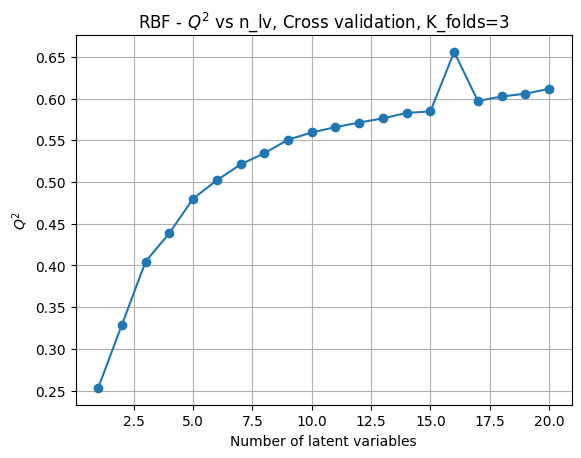

Best CV n_lv=16, gamma=0.000476495, Q^2=0.6560
Evaluate n. 0, gamma=0.8200094967106035, n_lv=1
Evaluate n. 1, gamma=0.9854341197457558, n_lv=2
Evaluate n. 2, gamma=0.6822042878684775, n_lv=3
Evaluate n. 3, gamma=0.46096514758399415, n_lv=4
Evaluate n. 4, gamma=0.31056955346441995, n_lv=5
Evaluate n. 5, gamma=0.27011156782547757, n_lv=6
Evaluate n. 6, gamma=0.38470415107069045, n_lv=7
Evaluate n. 7, gamma=0.3743854373804567, n_lv=8
Evaluate n. 8, gamma=0.32384608045898183, n_lv=9
Evaluate n. 9, gamma=0.2574367399774277, n_lv=10
Evaluate n. 10, gamma=0.2619373980634943, n_lv=11
Evaluate n. 11, gamma=0.20082927559558028, n_lv=12
Evaluate n. 12, gamma=0.21885110095526655, n_lv=13
Evaluate n. 13, gamma=0.1841573820034479, n_lv=14
Evaluate n. 14, gamma=0.33738076459571553, n_lv=15
Evaluate n. 15, gamma=0.0004764947003559575, n_lv=16
Evaluate n. 16, gamma=0.2149277469445256, n_lv=17
Evaluate n. 17, gamma=0.16266171405456376, n_lv=18
Evaluate n. 18, gamma=0.15293388740470326, n_lv=19
Evaluate 

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 2, gamma: 1.2991356937595249, q2: 0.37704708584269114
n_lv: 3, gamma: 1.4661846122358402, q2: 0.41734249063713746
n_lv: 4, gamma: 2.8902412275378806, q2: 0.4459743899981963
n_lv: 1, gamma: 14.609453310935661, q2: 0.27537454622864194
n_lv: 5, gamma: 4.36469912791204, q2: 0.49423662688539355


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  3.1min


n_lv: 6, gamma: 4.310162971342663, q2: 0.5162755772890626
n_lv: 7, gamma: 1.4475630288383228, q2: 0.5324153157151544
n_lv: 8, gamma: 0.7501673834466949, q2: 0.548163528158389
n_lv: 9, gamma: 0.4063970655967034, q2: 0.5549097030697998
n_lv: 11, gamma: 1.835859910949726, q2: 0.5766416298225727


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  6.3min


n_lv: 10, gamma: 0.40433986417726797, q2: 0.5661009652041946
n_lv: 12, gamma: 1.0649760765824972, q2: 0.5900184808767172
n_lv: 13, gamma: 0.8217080854877615, q2: 0.5962732309209767
n_lv: 14, gamma: 0.8163369866314942, q2: 0.6012693020513725
n_lv: 15, gamma: 0.8176711155501375, q2: 0.6052978868877191
n_lv: 16, gamma: 0.663007026144369, q2: 0.6102406942575257


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed: 12.2min remaining:  3.1min


n_lv: 17, gamma: 0.7633722895703152, q2: 0.61427158649641
n_lv: 19, gamma: 0.24880618969865448, q2: 0.624186507701269
n_lv: 18, gamma: 0.2847282943077011, q2: 0.6194359143835635
n_lv: 20, gamma: 0.3842040367254075, q2: 0.6259887323048317


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed: 15.7min finished


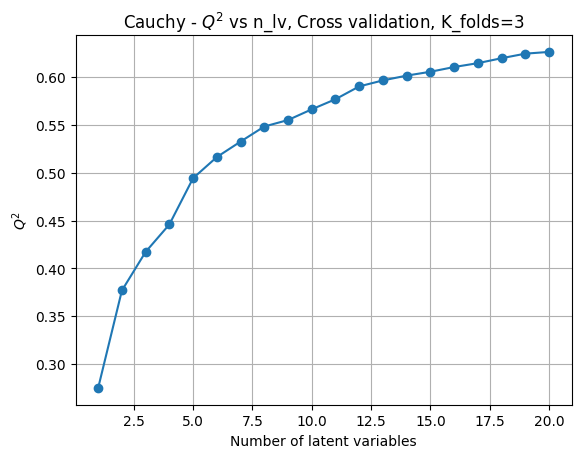

Best CV n_lv=20, gamma=0.384204, Q^2=0.6260
Evaluate n. 0, gamma=14.609453310935661, n_lv=1
Evaluate n. 1, gamma=1.2991356937595249, n_lv=2
Evaluate n. 2, gamma=1.4661846122358402, n_lv=3
Evaluate n. 3, gamma=2.8902412275378806, n_lv=4
Evaluate n. 4, gamma=4.36469912791204, n_lv=5
Evaluate n. 5, gamma=4.310162971342663, n_lv=6
Evaluate n. 6, gamma=1.4475630288383228, n_lv=7
Evaluate n. 7, gamma=0.7501673834466949, n_lv=8
Evaluate n. 8, gamma=0.4063970655967034, n_lv=9
Evaluate n. 9, gamma=0.40433986417726797, n_lv=10
Evaluate n. 10, gamma=1.835859910949726, n_lv=11
Evaluate n. 11, gamma=1.0649760765824972, n_lv=12
Evaluate n. 12, gamma=0.8217080854877615, n_lv=13
Evaluate n. 13, gamma=0.8163369866314942, n_lv=14
Evaluate n. 14, gamma=0.8176711155501375, n_lv=15
Evaluate n. 15, gamma=0.663007026144369, n_lv=16
Evaluate n. 16, gamma=0.7633722895703152, n_lv=17
Evaluate n. 17, gamma=0.2847282943077011, n_lv=18
Evaluate n. 18, gamma=0.24880618969865448, n_lv=19
Evaluate n. 19, gamma=0.3842

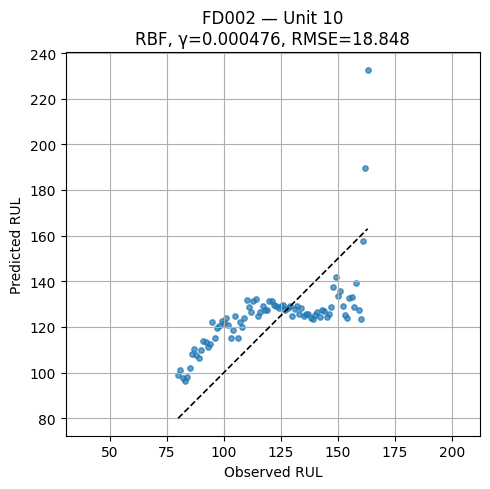

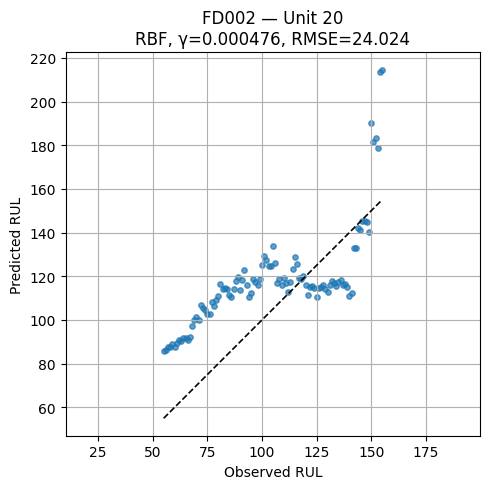

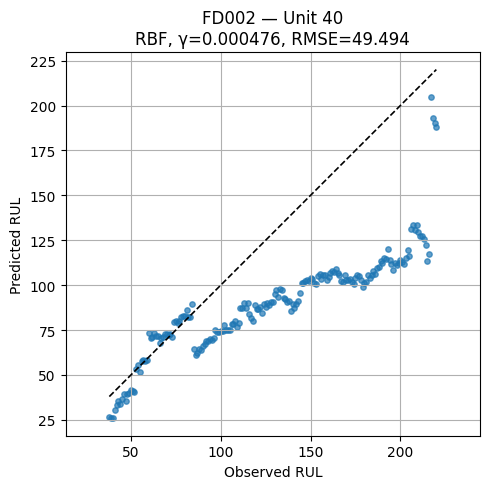

Zero variance columns (constant values): ['sensor measurement 1', 'sensor measurement 5', 'sensor measurement 16', 'sensor measurement 18', 'sensor measurement 19']
['sensor measurement 2', 'sensor measurement 3', 'sensor measurement 4', 'sensor measurement 6', 'sensor measurement 7', 'sensor measurement 8', 'sensor measurement 9', 'sensor measurement 10', 'sensor measurement 11', 'sensor measurement 12', 'sensor measurement 13', 'sensor measurement 14', 'sensor measurement 15', 'sensor measurement 17', 'sensor measurement 20', 'sensor measurement 21', 'SM1_mean', 'SM1_max', 'SM1_min', 'SM2_mean', 'SM2_max', 'SM2_min', 'SM3_mean', 'SM3_max', 'SM3_min', 'SM4_mean', 'SM4_max', 'SM4_min', 'SM5_mean', 'SM5_max', 'SM5_min', 'SM6_mean', 'SM6_max', 'SM6_min', 'SM7_mean', 'SM7_max', 'SM7_min', 'SM8_mean', 'SM8_max', 'SM8_min', 'SM9_mean', 'SM9_max', 'SM9_min', 'SM10_mean', 'SM10_max', 'SM10_min', 'SM11_mean', 'SM11_max', 'SM11_min', 'SM12_mean', 'SM12_max', 'SM12_min', 'SM13_mean', 'SM13_max',

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 2, gamma: 0.001943241587610851, q2: 0.5483519231417009
n_lv: 3, gamma: 0.005193759836090057, q2: 0.5575471382508921
n_lv: 1, gamma: 9.999497540716856, q2: 0.15241486210591704
n_lv: 4, gamma: 0.0038000557871437587, q2: 0.5904718419362566
n_lv: 5, gamma: 0.002730529646850684, q2: 0.607105962814342


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  5.4min


n_lv: 6, gamma: 0.0034667223974464896, q2: 0.6048660894924309
n_lv: 7, gamma: 0.0036016313151723475, q2: 0.6172675607859016
n_lv: 8, gamma: 0.0041550317022277655, q2: 0.6207693835548098
n_lv: 10, gamma: 0.060458084655129515, q2: 0.576181248804013
n_lv: 9, gamma: 0.0038000557871437587, q2: 0.6174723058170591


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  8.9min


n_lv: 11, gamma: 9.999338996493444, q2: 0.3346598575586934
n_lv: 12, gamma: 9.999338996493444, q2: 0.35305602440781647
n_lv: 14, gamma: 0.022713856912487573, q2: 0.591677547165379
n_lv: 13, gamma: 9.999338996493444, q2: 0.34600844047443285
n_lv: 15, gamma: 9.999338996493444, q2: 0.3809511585346023
n_lv: 16, gamma: 9.999454172273257, q2: 0.3803633292640118


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed: 14.5min remaining:  3.6min


n_lv: 17, gamma: 9.999415543818916, q2: 0.3556616869631829
n_lv: 18, gamma: 9.999544023679087, q2: 0.2898759916361515
n_lv: 19, gamma: 9.999587637499339, q2: 0.19779481086081396
n_lv: 20, gamma: 9.999338996493444, q2: 0.1868517311290015


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed: 19.1min finished


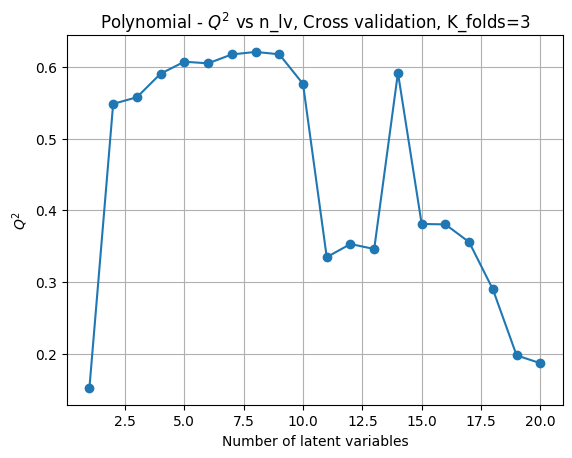

Best CV n_lv=8, gamma=0.00415503, Q^2=0.6208
Skipping eval 0 -> cv Q^2 is less than 0.2
Evaluate n. 1, gamma=0.001943241587610851, n_lv=2
Evaluate n. 2, gamma=0.005193759836090057, n_lv=3
Evaluate n. 3, gamma=0.0038000557871437587, n_lv=4
Evaluate n. 4, gamma=0.002730529646850684, n_lv=5
Evaluate n. 5, gamma=0.0034667223974464896, n_lv=6
Evaluate n. 6, gamma=0.0036016313151723475, n_lv=7
Evaluate n. 7, gamma=0.0041550317022277655, n_lv=8
Evaluate n. 8, gamma=0.0038000557871437587, n_lv=9
Evaluate n. 9, gamma=0.060458084655129515, n_lv=10
Evaluate n. 10, gamma=9.999338996493444, n_lv=11
Evaluate n. 11, gamma=9.999338996493444, n_lv=12
Evaluate n. 12, gamma=9.999338996493444, n_lv=13
Evaluate n. 13, gamma=0.022713856912487573, n_lv=14
Evaluate n. 14, gamma=9.999338996493444, n_lv=15
Evaluate n. 15, gamma=9.999454172273257, n_lv=16
Evaluate n. 16, gamma=9.999415543818916, n_lv=17
Evaluate n. 17, gamma=9.999544023679087, n_lv=18
Skipping eval 18 -> cv Q^2 is less than 0.2
Skipping eval 19 

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 1, gamma: 0.00066940108373409, q2: 0.5394790327764607
n_lv: 3, gamma: 0.03915579005471529, q2: 0.49808487602352663
n_lv: 2, gamma: 0.0004996866006833863, q2: 0.5484568854802785
n_lv: 4, gamma: 0.010407395345203513, q2: 0.5626544428545168
n_lv: 5, gamma: 0.004337899300681751, q2: 0.6046249850414583


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  4.2min


n_lv: 8, gamma: 0.012301830677138016, q2: 0.614286036826844
n_lv: 7, gamma: 0.008553334809252277, q2: 0.6141084885822178
n_lv: 6, gamma: 0.0015364711852409096, q2: 0.6158409970213374
n_lv: 9, gamma: 0.008094192017828742, q2: 0.6179651562646492
n_lv: 10, gamma: 0.006790681236118846, q2: 0.621792131599427


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  7.2min


n_lv: 11, gamma: 0.002148897252288797, q2: 0.6208932742577762
n_lv: 12, gamma: 0.005661856725379861, q2: 0.6202260664448077
n_lv: 13, gamma: 0.004567711914679218, q2: 0.6181643949884141
n_lv: 14, gamma: 0.003636223090080921, q2: 0.6143996657841546
n_lv: 15, gamma: 0.0034822307526683814, q2: 0.6096355473493
n_lv: 16, gamma: 0.0009921827530931264, q2: 0.6113514097920203


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed: 12.6min remaining:  3.2min


n_lv: 17, gamma: 0.013368766738842268, q2: 0.6025646516028219
n_lv: 18, gamma: 0.012447182264562262, q2: 0.5968809420309498
n_lv: 19, gamma: 0.00043730322404093283, q2: 0.6119431715697352
n_lv: 20, gamma: 0.00066940108373409, q2: 0.6105959115241255


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed: 16.4min finished


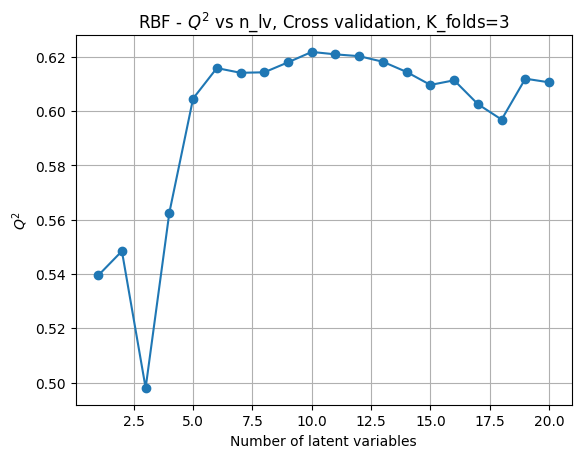

Best CV n_lv=10, gamma=0.00679068, Q^2=0.6218
Evaluate n. 0, gamma=0.00066940108373409, n_lv=1
Evaluate n. 1, gamma=0.0004996866006833863, n_lv=2
Evaluate n. 2, gamma=0.03915579005471529, n_lv=3
Evaluate n. 3, gamma=0.010407395345203513, n_lv=4
Evaluate n. 4, gamma=0.004337899300681751, n_lv=5
Evaluate n. 5, gamma=0.0015364711852409096, n_lv=6
Evaluate n. 6, gamma=0.008553334809252277, n_lv=7
Evaluate n. 7, gamma=0.012301830677138016, n_lv=8
Evaluate n. 8, gamma=0.008094192017828742, n_lv=9
Evaluate n. 9, gamma=0.006790681236118846, n_lv=10
Evaluate n. 10, gamma=0.002148897252288797, n_lv=11
Evaluate n. 11, gamma=0.005661856725379861, n_lv=12
Evaluate n. 12, gamma=0.004567711914679218, n_lv=13
Evaluate n. 13, gamma=0.003636223090080921, n_lv=14
Evaluate n. 14, gamma=0.0034822307526683814, n_lv=15
Evaluate n. 15, gamma=0.0009921827530931264, n_lv=16
Evaluate n. 16, gamma=0.013368766738842268, n_lv=17
Evaluate n. 17, gamma=0.012447182264562262, n_lv=18
Evaluate n. 18, gamma=0.00043730322

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 3, gamma: 0.34721688002868195, q2: 0.5033294074158158
n_lv: 1, gamma: 0.0004988284833459791, q2: 0.5373120426965784
n_lv: 2, gamma: 0.0004988284833459791, q2: 0.5475831596155889
n_lv: 4, gamma: 0.017646584405060207, q2: 0.5940992675670668
n_lv: 5, gamma: 9.04188271564775, q2: 0.5475269326709002


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  2.5min


n_lv: 8, gamma: 2.679126309032057, q2: 0.5462086758291047
n_lv: 6, gamma: 0.003631580936212186, q2: 0.6134543395811912
n_lv: 7, gamma: 0.006331639182449089, q2: 0.6186135717546579
n_lv: 9, gamma: 0.005169726766670562, q2: 0.6190640963664071
n_lv: 10, gamma: 5.926871568334378, q2: 0.5437733866090769


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  6.5min


n_lv: 12, gamma: 4.848820109675951, q2: 0.5480108568715991
n_lv: 11, gamma: 4.141985146145223, q2: 0.5495724278031198
n_lv: 13, gamma: 3.00980117944752, q2: 0.5518124749112139
n_lv: 14, gamma: 4.412890098834255, q2: 0.5538351322100116
n_lv: 16, gamma: 2.3574463223331685, q2: 0.5567142071741092
n_lv: 15, gamma: 3.799919876184981, q2: 0.552493842931324


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed: 11.2min remaining:  2.8min


n_lv: 17, gamma: 3.338260449146531, q2: 0.5544360456953321
n_lv: 19, gamma: 3.5617769214053436, q2: 0.5527581023523057
n_lv: 18, gamma: 3.8467518065520325, q2: 0.5530816263040227
n_lv: 20, gamma: 2.48926359551207, q2: 0.5558570242387928


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed: 13.8min finished


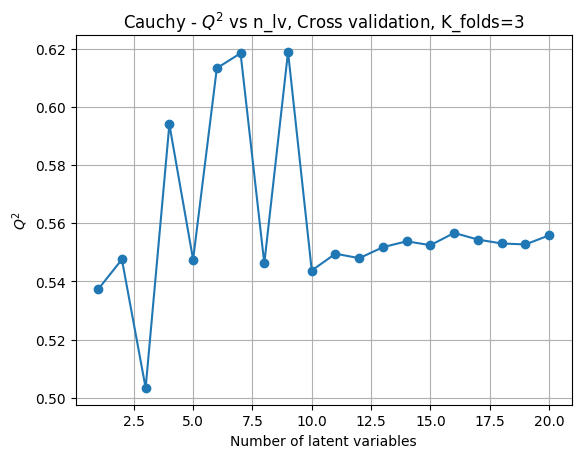

Best CV n_lv=9, gamma=0.00516973, Q^2=0.6191
Evaluate n. 0, gamma=0.0004988284833459791, n_lv=1
Evaluate n. 1, gamma=0.0004988284833459791, n_lv=2
Evaluate n. 2, gamma=0.34721688002868195, n_lv=3
Evaluate n. 3, gamma=0.017646584405060207, n_lv=4
Evaluate n. 4, gamma=9.04188271564775, n_lv=5
Evaluate n. 5, gamma=0.003631580936212186, n_lv=6
Evaluate n. 6, gamma=0.006331639182449089, n_lv=7
Evaluate n. 7, gamma=2.679126309032057, n_lv=8
Evaluate n. 8, gamma=0.005169726766670562, n_lv=9
Evaluate n. 9, gamma=5.926871568334378, n_lv=10
Evaluate n. 10, gamma=4.141985146145223, n_lv=11
Evaluate n. 11, gamma=4.848820109675951, n_lv=12
Evaluate n. 12, gamma=3.00980117944752, n_lv=13
Evaluate n. 13, gamma=4.412890098834255, n_lv=14
Evaluate n. 14, gamma=3.799919876184981, n_lv=15
Evaluate n. 15, gamma=2.3574463223331685, n_lv=16
Evaluate n. 16, gamma=3.338260449146531, n_lv=17
Evaluate n. 17, gamma=3.8467518065520325, n_lv=18
Evaluate n. 18, gamma=3.5617769214053436, n_lv=19
Evaluate n. 19, gamm

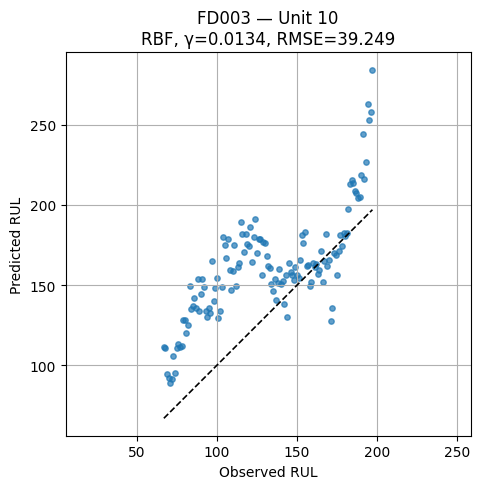

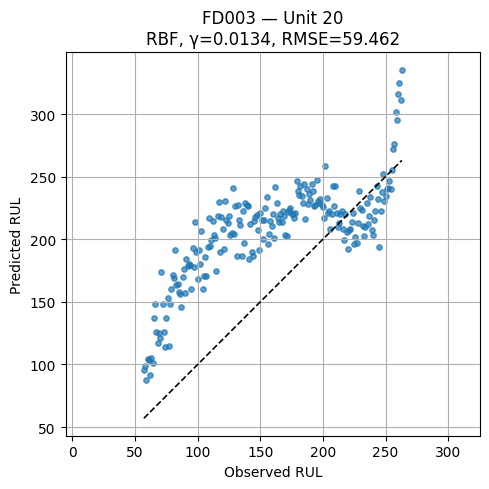

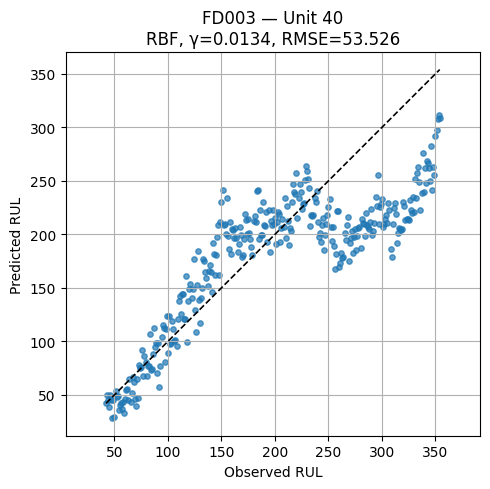

Zero variance columns (constant values): []
['sensor measurement 1', 'sensor measurement 2', 'sensor measurement 3', 'sensor measurement 4', 'sensor measurement 5', 'sensor measurement 6', 'sensor measurement 7', 'sensor measurement 8', 'sensor measurement 9', 'sensor measurement 10', 'sensor measurement 11', 'sensor measurement 12', 'sensor measurement 13', 'sensor measurement 14', 'sensor measurement 15', 'sensor measurement 16', 'sensor measurement 17', 'sensor measurement 18', 'sensor measurement 19', 'sensor measurement 20', 'sensor measurement 21', 'SM1_mean', 'SM1_max', 'SM1_min', 'SM2_mean', 'SM2_max', 'SM2_min', 'SM3_mean', 'SM3_max', 'SM3_min', 'SM4_mean', 'SM4_max', 'SM4_min', 'SM5_mean', 'SM5_max', 'SM5_min', 'SM6_mean', 'SM6_max', 'SM6_min', 'SM7_mean', 'SM7_max', 'SM7_min', 'SM8_mean', 'SM8_max', 'SM8_min', 'SM9_mean', 'SM9_max', 'SM9_min', 'SM10_mean', 'SM10_max', 'SM10_min', 'SM11_mean', 'SM11_max', 'SM11_min', 'SM12_mean', 'SM12_max', 'SM12_min', 'SM13_mean', 'SM13_max

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 1, gamma: 0.001661003506557609, q2: 0.038322982275490525
n_lv: 2, gamma: 0.0014083931347011864, q2: 0.05892348828124655
n_lv: 3, gamma: 0.0014028594171784747, q2: 0.10907931066401805
n_lv: 4, gamma: 0.003456618370984514, q2: 0.17473314405634338
n_lv: 5, gamma: 0.001661003506557609, q2: 0.3965441173901683


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  5.7min


n_lv: 6, gamma: 0.0013858227778544452, q2: 0.47328594439685306
n_lv: 7, gamma: 0.001661003506557609, q2: 0.49313505549022285
n_lv: 8, gamma: 0.0015667488797945638, q2: 0.5052310204707033
n_lv: 9, gamma: 9.999410277723282, q2: 0.0829872247940599
n_lv: 10, gamma: 0.002730529646850684, q2: 0.5467349854781326


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed: 10.2min


n_lv: 11, gamma: 0.0014028594171784747, q2: 0.574083258965871
n_lv: 12, gamma: 0.0015619504807298451, q2: 0.6052437264780856
n_lv: 13, gamma: 0.001438845377849317, q2: 0.638468730076534
n_lv: 14, gamma: 9.999338996493444, q2: 0.15080386175988747
n_lv: 16, gamma: 0.0014494573632652422, q2: 0.651206500219131
n_lv: 15, gamma: 0.0014699084227808136, q2: 0.6486788112212556


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed: 15.8min remaining:  4.0min


n_lv: 17, gamma: 0.002730529646850684, q2: 0.649107494316771
n_lv: 18, gamma: 9.999616455155143, q2: 0.2278129832599668
n_lv: 20, gamma: 0.0038000557871437587, q2: 0.6560723872395579
n_lv: 19, gamma: 9.99937166479352, q2: 0.24725897907533323


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed: 20.8min finished


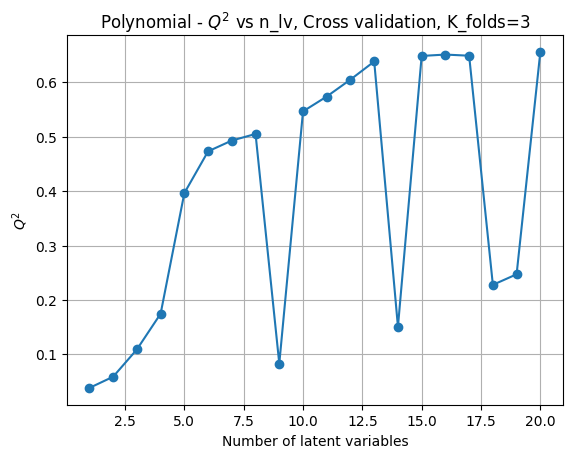

Best CV n_lv=20, gamma=0.00380006, Q^2=0.6561
Skipping eval 0 -> cv Q^2 is less than 0.2
Skipping eval 1 -> cv Q^2 is less than 0.2
Skipping eval 2 -> cv Q^2 is less than 0.2
Skipping eval 3 -> cv Q^2 is less than 0.2
Evaluate n. 4, gamma=0.001661003506557609, n_lv=5
Evaluate n. 5, gamma=0.0013858227778544452, n_lv=6
Evaluate n. 6, gamma=0.001661003506557609, n_lv=7
Evaluate n. 7, gamma=0.0015667488797945638, n_lv=8
Skipping eval 8 -> cv Q^2 is less than 0.2
Evaluate n. 9, gamma=0.002730529646850684, n_lv=10
Evaluate n. 10, gamma=0.0014028594171784747, n_lv=11
Evaluate n. 11, gamma=0.0015619504807298451, n_lv=12
Evaluate n. 12, gamma=0.001438845377849317, n_lv=13
Skipping eval 13 -> cv Q^2 is less than 0.2
Evaluate n. 14, gamma=0.0014699084227808136, n_lv=15
Evaluate n. 15, gamma=0.0014494573632652422, n_lv=16
Evaluate n. 16, gamma=0.002730529646850684, n_lv=17
Evaluate n. 17, gamma=9.999616455155143, n_lv=18
Evaluate n. 18, gamma=9.99937166479352, n_lv=19
Evaluate n. 19, gamma=0.00380

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 2, gamma: 0.7340311065111527, q2: 0.3826745188054898
n_lv: 1, gamma: 0.9492254246669248, q2: 0.2764545514923072
n_lv: 3, gamma: 0.6014044313353574, q2: 0.47162081014631574
n_lv: 4, gamma: 0.4480602929354184, q2: 0.5029241480804955
n_lv: 5, gamma: 0.42411476076492943, q2: 0.5330290531923971


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  2.8min


n_lv: 6, gamma: 0.40806270488534163, q2: 0.5566053315483056
n_lv: 7, gamma: 0.3379451074291073, q2: 0.5717491875017544
n_lv: 8, gamma: 0.32424560412558506, q2: 0.5906321252083825
n_lv: 9, gamma: 0.2809543377293558, q2: 0.5988163892161515
n_lv: 10, gamma: 0.25352295591761487, q2: 0.6026270772573986


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  5.7min


n_lv: 11, gamma: 0.22665700678993872, q2: 0.6051353917626308
n_lv: 12, gamma: 0.2748622032561352, q2: 0.6096080110961014
n_lv: 13, gamma: 0.23722144306421605, q2: 0.6135291167331198
n_lv: 14, gamma: 0.24385571819996163, q2: 0.6197762753559592
n_lv: 15, gamma: 0.22009696400980874, q2: 0.6225340760166508
n_lv: 17, gamma: 0.22577003335904675, q2: 0.6293342897639959


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed: 12.1min remaining:  3.0min


n_lv: 16, gamma: 0.18799154670158877, q2: 0.6255883334359909
n_lv: 18, gamma: 0.21378023141366137, q2: 0.6321234285948136
n_lv: 19, gamma: 0.16972629829620572, q2: 0.6346703855527437
n_lv: 20, gamma: 0.22018660468539047, q2: 0.6378491168450845


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed: 15.5min finished


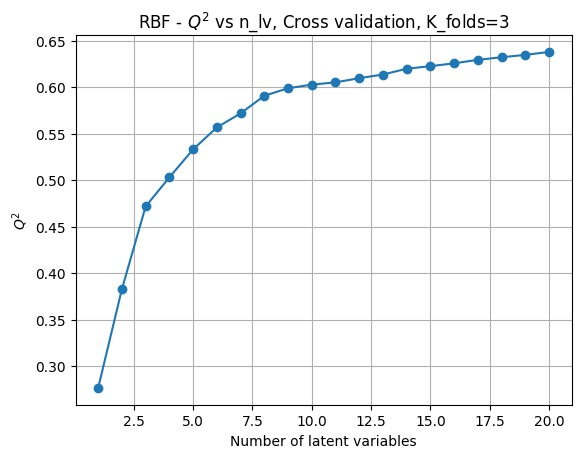

Best CV n_lv=20, gamma=0.220187, Q^2=0.6378
Evaluate n. 0, gamma=0.9492254246669248, n_lv=1
Evaluate n. 1, gamma=0.7340311065111527, n_lv=2
Evaluate n. 2, gamma=0.6014044313353574, n_lv=3
Evaluate n. 3, gamma=0.4480602929354184, n_lv=4
Evaluate n. 4, gamma=0.42411476076492943, n_lv=5
Evaluate n. 5, gamma=0.40806270488534163, n_lv=6
Evaluate n. 6, gamma=0.3379451074291073, n_lv=7
Evaluate n. 7, gamma=0.32424560412558506, n_lv=8
Evaluate n. 8, gamma=0.2809543377293558, n_lv=9
Evaluate n. 9, gamma=0.25352295591761487, n_lv=10
Evaluate n. 10, gamma=0.22665700678993872, n_lv=11
Evaluate n. 11, gamma=0.2748622032561352, n_lv=12
Evaluate n. 12, gamma=0.23722144306421605, n_lv=13
Evaluate n. 13, gamma=0.24385571819996163, n_lv=14
Evaluate n. 14, gamma=0.22009696400980874, n_lv=15
Evaluate n. 15, gamma=0.18799154670158877, n_lv=16
Evaluate n. 16, gamma=0.22577003335904675, n_lv=17
Evaluate n. 17, gamma=0.21378023141366137, n_lv=18
Evaluate n. 18, gamma=0.16972629829620572, n_lv=19
Evaluate n. 1

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 4, gamma: 11.55152858887921, q2: 0.4882655040027
n_lv: 2, gamma: 2.469128378690334, q2: 0.36279166604441737
n_lv: 3, gamma: 1.7528648111583127, q2: 0.41843119949817104
n_lv: 1, gamma: 14.178809017754036, q2: 0.25372517546951073
n_lv: 5, gamma: 6.743441335620099, q2: 0.5218873337130269


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  2.9min


n_lv: 6, gamma: 2.9563349879714567, q2: 0.5435538113138576
n_lv: 7, gamma: 2.144604902262818, q2: 0.5597710945471115
n_lv: 8, gamma: 1.5664015168919836, q2: 0.5773575890552891
n_lv: 9, gamma: 1.8028856816246093, q2: 0.5886135397642753
n_lv: 10, gamma: 1.4019413234121783, q2: 0.5983885427568914


[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  6.4min


n_lv: 11, gamma: 1.5698779269331518, q2: 0.6172634220333123
n_lv: 12, gamma: 0.9873479520813073, q2: 0.6229066818514503
n_lv: 13, gamma: 1.0574459788568893, q2: 0.6275143800671075
n_lv: 15, gamma: 0.8129443273066235, q2: 0.6379984673639246
n_lv: 14, gamma: 1.0531962316081802, q2: 0.6352250983031503
n_lv: 16, gamma: 0.5051918936135955, q2: 0.6420700265116179


[Parallel(n_jobs=4)]: Done  16 out of  20 | elapsed: 10.8min remaining:  2.7min


n_lv: 17, gamma: 0.47213930654472325, q2: 0.6441022821993072
n_lv: 19, gamma: 0.5162714818424678, q2: 0.650042118032615
n_lv: 18, gamma: 0.28187008788998746, q2: 0.6468612482974657
n_lv: 20, gamma: 0.7952196242167693, q2: 0.6520643451224666


[Parallel(n_jobs=4)]: Done  20 out of  20 | elapsed: 13.8min finished


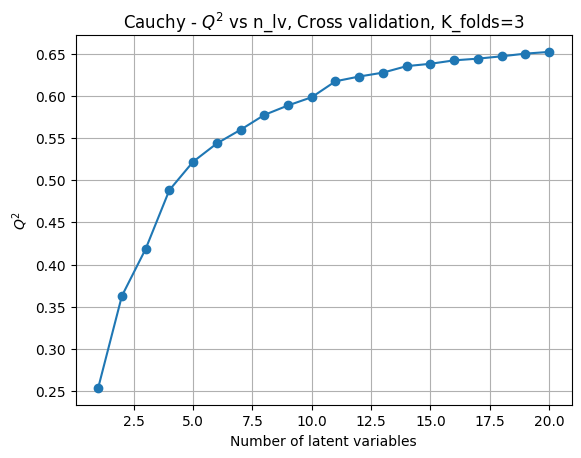

Best CV n_lv=20, gamma=0.79522, Q^2=0.6521
Evaluate n. 0, gamma=14.178809017754036, n_lv=1
Evaluate n. 1, gamma=2.469128378690334, n_lv=2
Evaluate n. 2, gamma=1.7528648111583127, n_lv=3
Evaluate n. 3, gamma=11.55152858887921, n_lv=4
Evaluate n. 4, gamma=6.743441335620099, n_lv=5
Evaluate n. 5, gamma=2.9563349879714567, n_lv=6
Evaluate n. 6, gamma=2.144604902262818, n_lv=7
Evaluate n. 7, gamma=1.5664015168919836, n_lv=8
Evaluate n. 8, gamma=1.8028856816246093, n_lv=9
Evaluate n. 9, gamma=1.4019413234121783, n_lv=10
Evaluate n. 10, gamma=1.5698779269331518, n_lv=11
Evaluate n. 11, gamma=0.9873479520813073, n_lv=12
Evaluate n. 12, gamma=1.0574459788568893, n_lv=13
Evaluate n. 13, gamma=1.0531962316081802, n_lv=14
Evaluate n. 14, gamma=0.8129443273066235, n_lv=15
Evaluate n. 15, gamma=0.5051918936135955, n_lv=16
Evaluate n. 16, gamma=0.47213930654472325, n_lv=17
Evaluate n. 17, gamma=0.28187008788998746, n_lv=18
Evaluate n. 18, gamma=0.5162714818424678, n_lv=19
Evaluate n. 19, gamma=0.7952

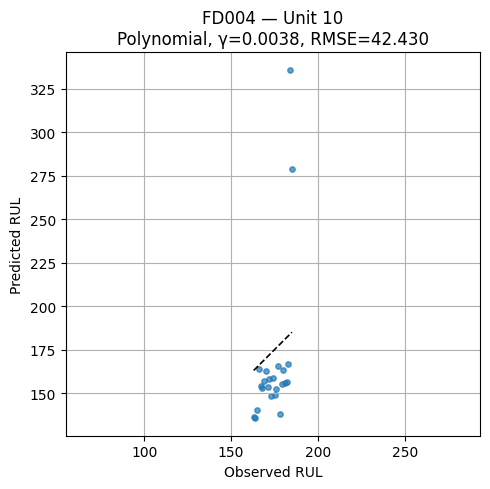

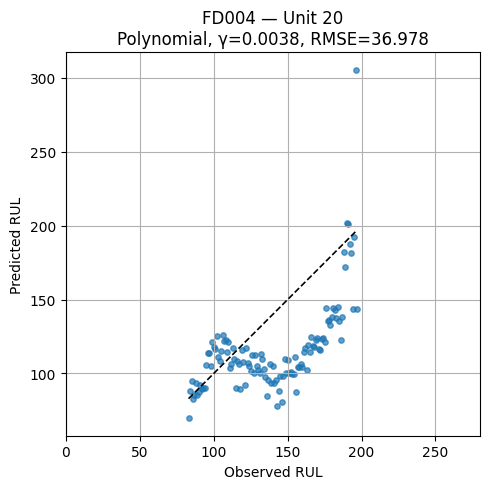

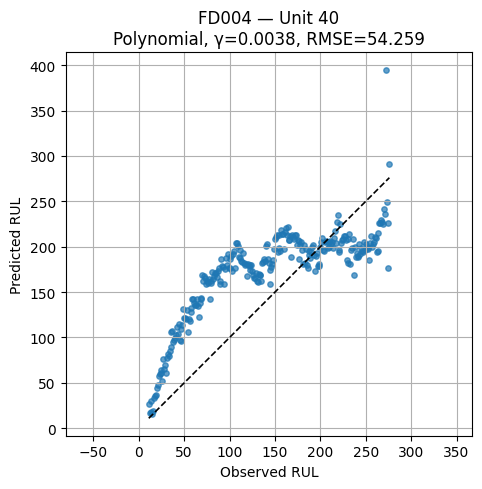

In [18]:
max_lv = 20
subset_size = 20000

train_data1, validation_data1, dropped_cols1 = train_from_file("./NASA-Turbofan-data/data/train_FD001.txt")
test_data1 = test_from_file("./NASA-Turbofan-data/data/test_FD001.txt", "./NASA-Turbofan-data/data/RUL_FD001.txt", dropped_cols=dropped_cols1)
train_data1, validation_data1, test_data1, mu_train1, sd_train1 = normalize_data(train_data1, validation_data1, test_data1)
process_dataset(train_data1, validation_data1, test_data1, "FD001", max_lv, train_subset_size=None, n_jobs=4)

train_data2, validation_data2, dropped_cols2 = train_from_file("./NASA-Turbofan-data/data/train_FD002.txt")
test_data2 = test_from_file("./NASA-Turbofan-data/data/test_FD002.txt", "./NASA-Turbofan-data/data/RUL_FD002.txt", dropped_cols=dropped_cols2)
train_data2 = subsample_time_series(
        train_data2, target_rows=subset_size,
        unit_col="unit number", order_col=None,
        keep_tail=50, min_per_unit=40, seed=42
    )

train_data2, validation_data2, test_data2, mu_train2, sd_train2 = normalize_data(train_data2, validation_data2, test_data2)
process_dataset(train_data2, validation_data2, test_data2, "FD002", max_lv, train_subset_size=None, n_jobs=4)

train_data3, validation_data3, dropped_cols3 = train_from_file("./NASA-Turbofan-data/data/train_FD003.txt")
test_data3 = test_from_file("./NASA-Turbofan-data/data/test_FD003.txt", "./NASA-Turbofan-data/data/RUL_FD003.txt", dropped_cols=dropped_cols3)
train_data3, validation_data3, test_data3, mu_train3, sd_train3 = normalize_data(train_data3, validation_data3, test_data3)
process_dataset(train_data3, validation_data3, test_data3, "FD003",max_lv, train_subset_size=None, n_jobs=4)

train_data4, validation_data4, dropped_cols4 = train_from_file("./NASA-Turbofan-data/data/train_FD004.txt")
test_data4 = test_from_file("./NASA-Turbofan-data/data/test_FD004.txt", "./NASA-Turbofan-data/data/RUL_FD004.txt", dropped_cols=dropped_cols4)
train_data4 = subsample_time_series(
        train_data4, target_rows=subset_size,
        unit_col="unit number", order_col=None,
        keep_tail=50, min_per_unit=40, seed=42
    )
train_data4, validation_data4, test_data4, mu_train4, sd_train4 = normalize_data(train_data4, validation_data4, test_data4)

process_dataset(train_data4, validation_data4, test_data4, "FD004",max_lv, train_subset_size=None, n_jobs=4)